# Shear modulus reconstruction - one inclusion (Fig 3.a, 4.a and 5.a)

In [ ]:
import dolfin as df
import math
import matplotlib.pyplot as plt
import numpy as np
import os

from Isotropic_case_forward_pb import isotropic_elasticity_problem
from Isotropic_case_VFM import VFM
from Type_3_VF import type_3
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### True parameter mu

In [11]:
# mu_1
class Mu1Expression(df.UserExpression):
    def eval(self, value, x):
        value[0]=0
        if (x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2 <= 0.2  ** 2:
            value[0]= 1
        elif 0.2  ** 2 <= (x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2 <= 0.25** 2:
            value[0] = (1 - (math.sqrt((x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2) - 0.2) / 0.05) ** 2 * (1 + 2 * (math.sqrt((x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2) - 0.2) / 0.05)
        value[0] = 1+value[0]
 
mu = Mu1Expression()


### Direct problem

In [12]:
omega, rho = 1, 1
degree = 3
dim = 2
Nx = 100
Ny = 100
u_boundary = df.Constant((0,0))  

mesh = df.UnitSquareMesh(Nx, Ny)
dx = df.Measure("dx", domain=mesh)
V_mu = df.FunctionSpace(mesh, 'CG', degree)

T=  df.Expression(('0', '2*sin(2*pi*x[0])'), degree=1)

f = df.Constant((0,0))
tol = 1e-15

mesh_params = {"Nx":Nx, "Ny":Ny, "degree":degree}
load_params = {"u_boundary":u_boundary, "f":f ,"T":T} 
mat_params  = {"mu":mu, "rho":rho, "omega":omega}

ureal, mu_function, ureal_norm = isotropic_elasticity_problem(
    mesh_params=mesh_params,
    mat_params=mat_params,
    load_params=load_params)

Solving linear variational problem.


### Plot mu

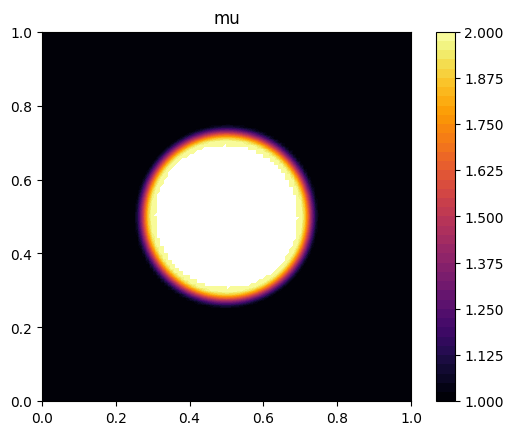

In [13]:
p=df.plot(mu_function, title="mu", cmap="inferno" )
plt.colorbar(p)
plt.show()
 

### PLot u

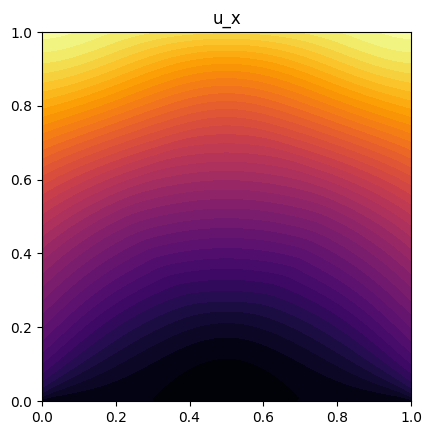

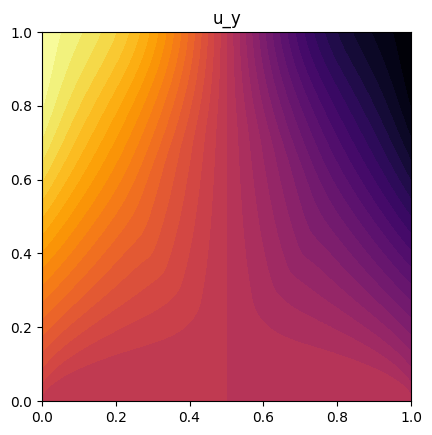

In [14]:
u1, u2 = ureal.split()
df.plot(u1, title="u_x", cmap="inferno")
plt.show()

df.plot(u2, title="u_y", cmap="inferno")
plt.show()

## Compare the three types of virtual fields - noiseless data

In [15]:
Error_list_Type1= []
Error_list_Type2= []
Error_list_Type3= []
SNR_list= [0]
V1 = ureal.function_space()
V_mu= mu_function.function_space()
mesh= V_mu.mesh()
dx = df.Measure("dx", domain=mesh)

phi_list = []
class phiExpression(df.UserExpression):
    def eval(self, value, x):
        value[0] = 0
        if (x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2 <= 0.2  ** 2:
            value[0] = 1
        elif 0.2  ** 2 <= (x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2 <= 0.25** 2:
            value[0] = (1 - (math.sqrt((x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2) - 0.2) / 0.05) ** 2 * (1 + 2 * (math.sqrt((x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2) - 0.2) / 0.05)
phi = phiExpression()
phi= df.interpolate(phi, V_mu)
phi_list.append(phi)

Q= df.FiniteElement('CG', mesh.ufl_cell(), degree=degree - 1)
Q1 = df.FunctionSpace(mesh, Q)
V = df.VectorElement('CG', mesh.ufl_cell(), degree=degree)
V1 = df.FunctionSpace(mesh, V)
V_mu = df.FunctionSpace(mesh, 'CG', degree)

def epsilon(u):
    return 0.5*(df.nabla_grad(u) + df.nabla_grad(u).T) 

### Type 1

In [16]:
alpha=1e10
mu_rec= VFM(phi_list, ureal, V_mu, V, Q, alpha, rho, omega) 
norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, Type 1, noiseless data :', norm1_l2) 
Error_list_Type1.append(norm1_l2*100)

Solving linear variational problem.
[[0.00252359]]
0.9999757163521457
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 1, noiseless data : 0.00023721517366198687


### Type 3

In [17]:
v2= type_3(mesh_params, Vertical_traction=True)
v2 = df.interpolate(v2, V1)
ureal = df.interpolate(ureal, V1)

alpha=  (rho*omega**2* df.assemble(df.inner(ureal,v2)*dx) - 2* df.assemble(df.inner(epsilon(ureal), epsilon(v2))*dx)) / (2*df.assemble( df.inner(phi  * epsilon(ureal), epsilon(v2))*dx)) 
print(alpha)
mu_rec = df.Function(V_mu)
mu_rec = df.project(1+alpha*phi ,V_mu) 
norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, Type 3, noiseless data :', norm1_l2) 
Error_list_Type3.append(norm1_l2*100)

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
1.0000817676191303
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 3, noiseless data : 0.0002390584564456314


### Type 2

In [18]:
class vExpression(df.UserExpression):
    def eval(self, value, x):
        value[0] = -x[1]*x[0]*(3*x[1]-2) 
        value[1] = (x[1]**2)*(x[1]-1)  
    def value_shape(self):
           return (2,)    
v1 = vExpression()
v1= df.interpolate(v1, V1)

alpha=  (rho*omega**2* df.assemble(df.inner(ureal,v1)*dx) - 2* df.assemble(df.inner(epsilon(ureal), epsilon(v1))*dx) )/ (2*df.assemble( df.inner(phi  * epsilon(ureal), epsilon(v1))*dx)) 
print(alpha)
mu_rec = df.Function(V_mu)
mu_rec = df.project(1+alpha*phi ,V_mu) 
norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
print('L2-norm error, Type 2, noiseless data :', norm1_l2) 
Error_list_Type2.append(norm1_l2*100)

Calling FFC just-in-time (JIT) compiler, this may take some time.
1.0000152650751337
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 2, noiseless data : 0.00023733791602797868


## Compare the three types of virtual fields - noisy data

In [19]:
Noise_list = np.array( [ 0.025**2, 0.05**2, 0.075**2, 0.10**2, 0.15**2, 0.20**2])
nb_noise = np.size(Noise_list)

h=ureal.vector().get_local()
a=h.shape 


In [20]:
for k in range(nb_noise) :  
    print("Noise = ", Noise_list[k])

    class noiseExpression(df.UserExpression):
        def eval(self, value, x):
           value[0]=0
           value[1]=0  
           for m  in range(1,10) :
                value[0] = value[0] +  Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs(Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal_norm
                value[1] = value[1] + Noise_list[k]*m/20*math.cos( 2*np.pi*x[0]*m/(20*math.sqrt(abs( Noise_list[k]))) )*math.cos( 2*np.pi*x[1]/(20*math.sqrt(abs( Noise_list[k]))) )*ureal_norm
        def value_shape(self):
           return (2,)
    
    noise_Expression= noiseExpression()
    noise_Expression= df.interpolate(noise_Expression, V1) 
    u_noised= df.Function(V1)    
    u_noised.vector()[:] = ureal.vector()[:]+ noise_Expression.vector()[:] 


    SNR = math.sqrt(df.assemble((epsilon(ureal) - epsilon(u_noised))**2 * dx ) + df.assemble((ureal - u_noised)**2 * dx) )/ ureal_norm 
    SNR_list.append(SNR*100)
    print("SNR", SNR)

    #Type 1:
    mu_rec= VFM(phi_list, u_noised, V_mu, V, Q, alpha, rho, omega) 
    norm1_l2 = math.sqrt(df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    Error_list_Type1.append(norm1_l2*100)
    print(f'L2-norm error, Type 1, noisy data {SNR}:', norm1_l2)

    #Type 2:
    alpha=  (rho*omega**2* df.assemble(df.inner(u_noised,v1)*dx) - 2* df.assemble(df.inner(epsilon(u_noised), epsilon(v1))*dx) )/ (2*df.assemble( df.inner(phi  * epsilon(u_noised), epsilon(v1))*dx)) 
    print(alpha)
    mu_rec = df.Function(V_mu)
    mu_rec = df.project(1+alpha*phi ,V_mu) 
    norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    print(f'L2-norm error, Type 2, noisy data {SNR}:', norm1_l2) 
    Error_list_Type2.append(norm1_l2*100)

    #Type 3:
    alpha=  (rho*omega**2* df.assemble(df.inner(u_noised,v2)*dx) - 2* df.assemble(df.inner(epsilon(u_noised), epsilon(v2))*dx) )/ (2*df.assemble( df.inner(phi  * epsilon(u_noised), epsilon(v2))*dx)) 
    print(alpha)
    mu_rec = df.Function(V_mu)
    mu_rec = df.project(1+alpha*phi ,V_mu) 
    norm1_l2 = math.sqrt( df.assemble((mu - mu_rec)**2 * dx)) / math.sqrt(df.assemble(mu**2 * dx))
    print(f'L2-norm error, Type 3, noisy data {SNR}:', norm1_l2) 
    Error_list_Type3.append(norm1_l2*100)
    

Noise =  0.0006250000000000001
SNR 0.030060523008805552
Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
[[0.00254204]]
0.9866599437433978
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 1, noisy data 0.030060523008805552: 0.004270244319174105
0.9999051826624766
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 2, noisy data 0.030060523008805552: 0.0002386665315963667
1.0109757571323827
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 3, noisy data 0.030060523008805552: 0.003522811019247419
Noise =  0.0025000000000000005
SNR 0.06012524300853443
Solving linear variational problem.
[[0.00255088]]
0.9813722832279509
Calling FFC just-in-time (JIT) compiler, this may take some time.
L2-norm error, Type 1, noisy data 0.06012524300853443: 0.005959861816555315
0.9977514463059562
Calling FFC just-in-time (JIT) compiler, this may take

In [21]:
print(SNR_list)
print(Error_list_Type1)
print(Error_list_Type2)
print(Error_list_Type3)

[0, 3.006052300880555, 6.0125243008534435, 8.396576356443944, 12.0360278721705, 19.482942126906373, 32.951308881904865]
[0.023721517366198687, 0.4270244319174105, 0.5959861816555315, 0.6521439008293421, 0.16341060688375666, 1.1345027840006285, 16.063844702472522]
[0.023733791602797868, 0.02386665315963667, 0.07538375970335005, 2.465068635217641, 24.572662482922524, 25.27775503141758, 36.59035593620713]
[0.02390584564456314, 0.3522811019247419, 1.5881386210610624, 3.4409047458082256, 3.6165625559607957, 8.385150868872913, 61.840968566573395]


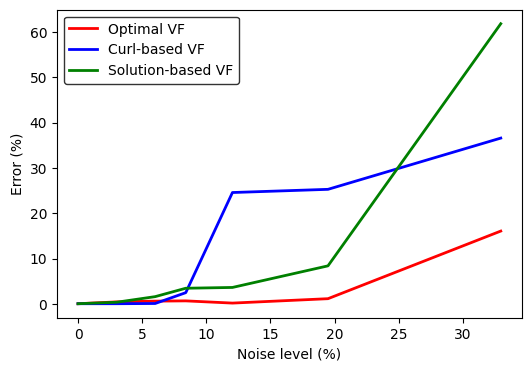

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))   

ax.plot(SNR_list, Error_list_Type1, "-r", label="Optimal VF", linewidth=2)
ax.plot(SNR_list, Error_list_Type2, "-b", label="Curl-based VF", linewidth=2)
ax.plot(SNR_list, Error_list_Type3, "-g", label="Solution-based VF", linewidth=2)

ax.set_xlabel('Noise level (%)')
ax.set_ylabel('Error (%)')


ax.legend(frameon=True, edgecolor="black", facecolor="white", fontsize=10,
          title_fontsize=10)

plt.show()
